<a href="https://colab.research.google.com/github/Deepak-tailor/Business-Case-Yulu---Hypothesis-Testing/blob/main/Yulu_Hypothesis_Testing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Yulu — Hypothesis Testing Business Case
### Factors Affecting Demand for Shared Electric Cycles in India

**Dataset:** `bike_sharing.csv` (10,886 hourly rental records, Jan 2011 – Dec 2012)

**Objective:** Identify which variables significantly predict demand for Yulu's shared electric cycles, and quantify how well those variables explain the variation in demand.

**Approach:** Exploratory Data Analysis followed by formal hypothesis tests (2-sample t-test, one-way ANOVA, Chi-square test of independence).

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option('display.width', 140)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 10})
sns.set_style('whitegrid')

%matplotlib inline

## 1. Load Data & Initial Inspection

In [ ]:
df = pd.read_csv('bike_sharing.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
print("Shape:", df.shape)
df.head()

Shape: (10886, 12)


,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10886 entries, 0 to 10885
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   datetime    10886 non-null  datetime64[us]
 1   season      10886 non-null  int64         
 2   holiday     10886 non-null  int64         
 3   workingday  10886 non-null  int64         
 4   weather     10886 non-null  int64         
 5   temp        10886 non-null  float64       
 6   atemp       10886 non-null  float64       
 7   humidity    10886 non-null  int64         
 8   windspeed   10886 non-null  float64       
 9   casual      10886 non-null  int64         
 10  registered  10886 non-null  int64         
 11  count       10886 non-null  int64         
dtypes: datetime64[us](1), float64(3), int64(8)
memory usage: 1020.7 KB


In [ ]:
print("Missing values per column:")
print(df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
print("\nDate range:", df['datetime'].min(), "to", df['datetime'].max())
print("\ncasual + registered == count check:", (df['casual'] + df['registered'] == df['count']).all())

Missing values per column:
datetime      0
season        0
holiday       0
workingday    0
weather       0
temp          0
atemp         0
humidity      0
windspeed     0
casual        0
registered    0
count         0
dtype: int64

Duplicate rows: 0

Date range: 2011-01-01 00:00:00 to 2012-12-19 23:00:00

casual + registered == count check: True


**Observations:**
- 10,886 rows, 12 columns, no missing values, no duplicate rows.
- Data spans exactly two years (Jan 2011 – Dec 2012), recorded hourly.
- `count` is verified to always equal `casual + registered`.
- `season`, `holiday`, `workingday`, and `weather` are integer-coded categoricals and should be converted to the `category` dtype for clarity in analysis.

In [ ]:
cat_cols = ['season', 'holiday', 'workingday', 'weather']
for c in cat_cols:
    df[c] = df[c].astype('category')

season_labels = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
weather_labels = {1: 'Clear', 2: 'Mist/Cloudy', 3: 'Light Rain/Snow', 4: 'Heavy Rain/Snow'}
binary_labels = {0: 'No', 1: 'Yes'}

df_lab = df.copy()
df_lab['season_lab'] = df_lab['season'].map(season_labels)
df_lab['weather_lab'] = df_lab['weather'].map(weather_labels)
df_lab['holiday_lab'] = df_lab['holiday'].map(binary_labels)
df_lab['workingday_lab'] = df_lab['workingday'].map(binary_labels)
df_lab.head()

,datetime,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,season_lab,weather_lab,holiday_lab,workingday_lab
0,2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,Spring,Clear,No,No
1,2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,Spring,Clear,No,No
2,2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,Spring,Clear,No,No
3,2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,Spring,Clear,No,No
4,2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,Spring,Clear,No,No


## 2. Statistical Summary

In [ ]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
datetime,10886,2011-12-27 05:56:22.399412,2011-01-01 00:00:00,2011-07-02 07:15:00,2012-01-01 20:30:00,2012-07-01 12:45:00,2012-12-19 23:00:00,NaN
temp,10886.0,20.23086,0.82,13.94,20.5,26.24,41.0,7.79159
atemp,10886.0,23.655084,0.76,16.665,24.24,31.06,45.455,8.474601
humidity,10886.0,61.88646,0.0,47.0,62.0,77.0,100.0,19.245033
windspeed,10886.0,12.799395,0.0,7.0015,12.998,16.9979,56.9969,8.164537
casual,10886.0,36.021955,0.0,4.0,17.0,49.0,367.0,49.960477
registered,10886.0,155.552177,0.0,36.0,118.0,222.0,886.0,151.039033
count,10886.0,191.574132,1.0,42.0,145.0,284.0,977.0,181.144454


In [ ]:
for c in cat_cols:
    print(f"\n{c} value counts:")
    print(df[c].value_counts().sort_index())


season value counts:
season
1    2686
2    2733
3    2733
4    2734
Name: count, dtype: int64

holiday value counts:
holiday
0    10575
1      311
Name: count, dtype: int64

workingday value counts:
workingday
0    3474
1    7412
Name: count, dtype: int64

weather value counts:
weather
1    7192
2    2834
3     859
4       1
Name: count, dtype: int64


**Observations:**
- The four seasons are almost equally represented (~2,700 hours each) — no imbalance to worry about when comparing seasons.
- 97.1% of hours are non-holidays; 68.1% are working days.
- 66.1% of hours have Clear weather; only a single hour (0.01%) is recorded as Heavy Rain/Snow — an extreme, effectively single-observation category that should be interpreted with caution wherever it appears in group comparisons.
- Average hourly rentals (`count`) is ~192, with a large standard deviation (~181) and a max of 977 — demand is highly variable and right-skewed (confirmed visually below).

## 3. Univariate Analysis

### 3.1 Continuous Variables

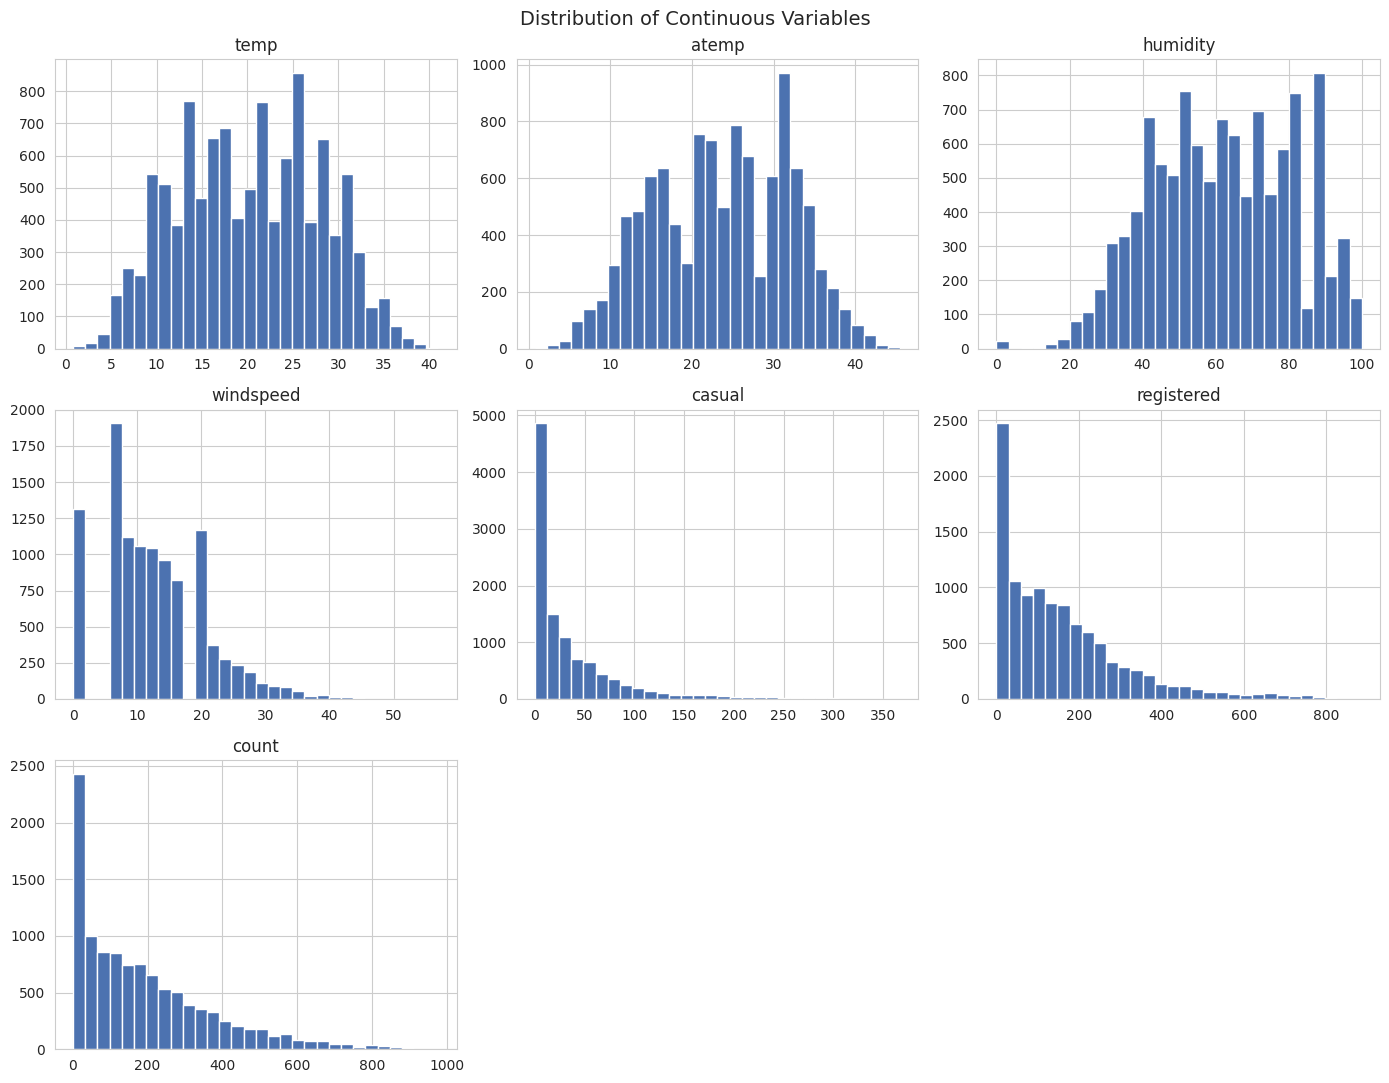

In [ ]:
cont_cols = ['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']
fig, axes = plt.subplots(3, 3, figsize=(14, 11))
axes = axes.flatten()
for i, col in enumerate(cont_cols):
    axes[i].hist(df[col], bins=30, color='#4C72B0', edgecolor='white')
    axes[i].set_title(col)
for j in range(len(cont_cols), len(axes)):
    fig.delaxes(axes[j])
fig.suptitle('Distribution of Continuous Variables', fontsize=14)
plt.tight_layout()
plt.show()

**Observations:**
- `temp` and `atemp` are fairly spread out across their range (0–41°C), reflecting the two-year seasonal cycle rather than a data issue; they are visibly near-identical in shape.
- `humidity` is left-skewed, concentrated between 40–90%, with a small cluster near 0%.
- `windspeed`, `casual`, `registered`, and `count` are all strongly **right-skewed** with a long tail of high-demand hours — typical of count data. This skew matters for the normality assumption checked later in hypothesis testing.
- `casual` riders are far fewer and more concentrated near zero than `registered` riders — registered (subscriber) users are the dominant demand segment.

### 3.2 Categorical Variables

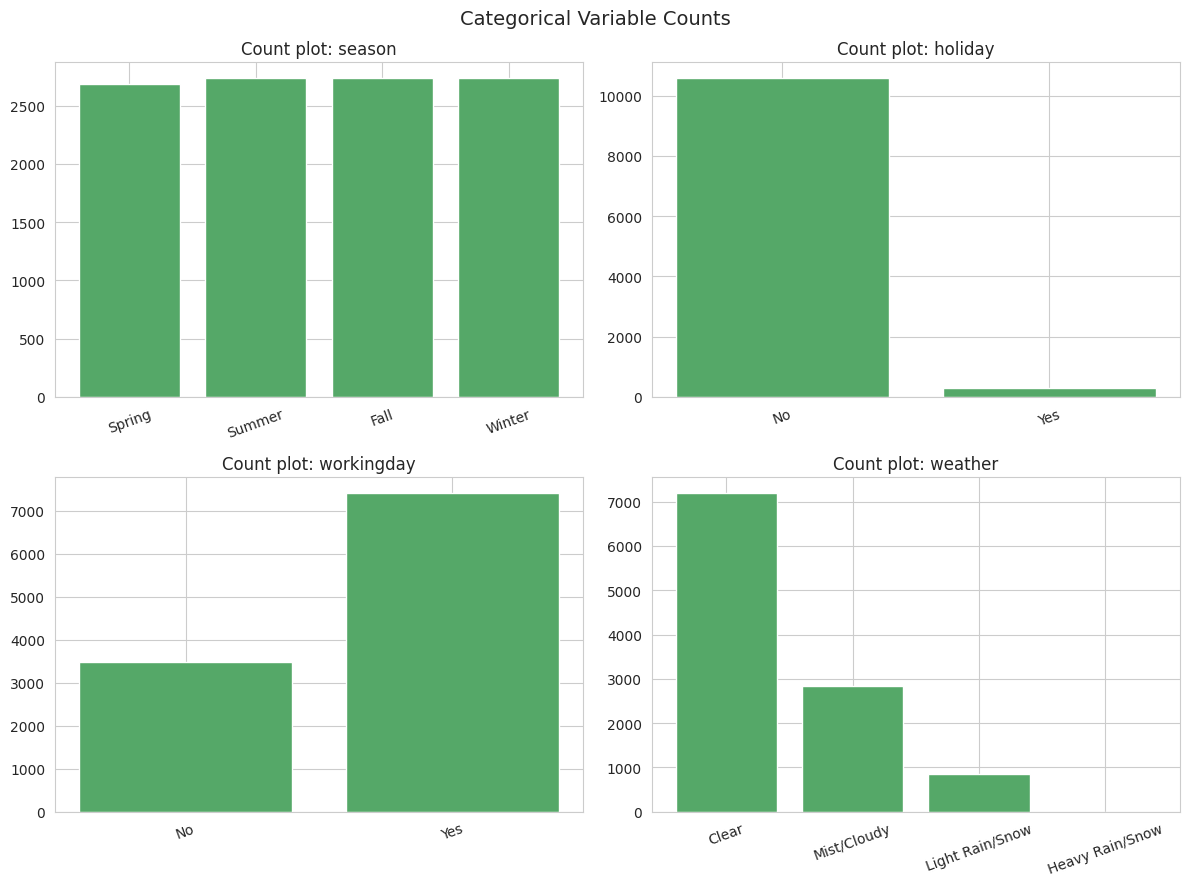

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()
order_map = {
    'season': ['Spring', 'Summer', 'Fall', 'Winter'],
    'holiday': ['No', 'Yes'],
    'workingday': ['No', 'Yes'],
    'weather': ['Clear', 'Mist/Cloudy', 'Light Rain/Snow', 'Heavy Rain/Snow']
}
lab_col_map = {'season': 'season_lab', 'holiday': 'holiday_lab', 'workingday': 'workingday_lab', 'weather': 'weather_lab'}
for i, col in enumerate(cat_cols):
    vc = df_lab[lab_col_map[col]].value_counts().reindex(order_map[col])
    axes[i].bar(vc.index, vc.values, color='#55A868')
    axes[i].set_title(f'Count plot: {col}')
    axes[i].tick_params(axis='x', rotation=20)
fig.suptitle('Categorical Variable Counts', fontsize=14)
plt.tight_layout()
plt.show()

**Observations:**
- The four seasons are almost equally represented, so seasonal comparisons are not confounded by sample-size imbalance.
- The overwhelming majority of hours are non-holidays (97%) and working days (68%).
- Clear weather dominates (66%); severe weather is extremely rare — only one hour of Heavy Rain/Snow in the entire two-year window.

## 4. Bivariate Analysis

### 4.1 Working Day vs. Count

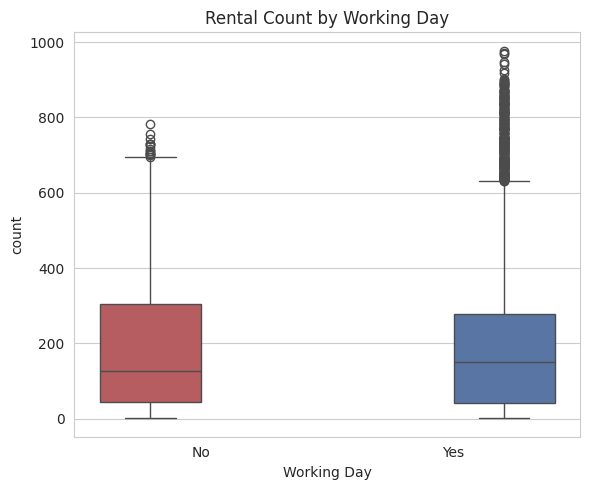

In [ ]:
fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(data=df_lab, x='workingday_lab', y='count', hue='workingday_lab', legend=False,
            palette=['#C44E52', '#4C72B0'], ax=ax)
ax.set_title('Rental Count by Working Day')
ax.set_xlabel('Working Day')
plt.tight_layout()
plt.show()

**Observation:** Median count is very similar between working and non-working days. Working days show a slightly wider spread with more high-demand outlier hours (likely commute peaks), while non-working day demand is more uniformly distributed across the day.

### 4.2 Season vs. Count

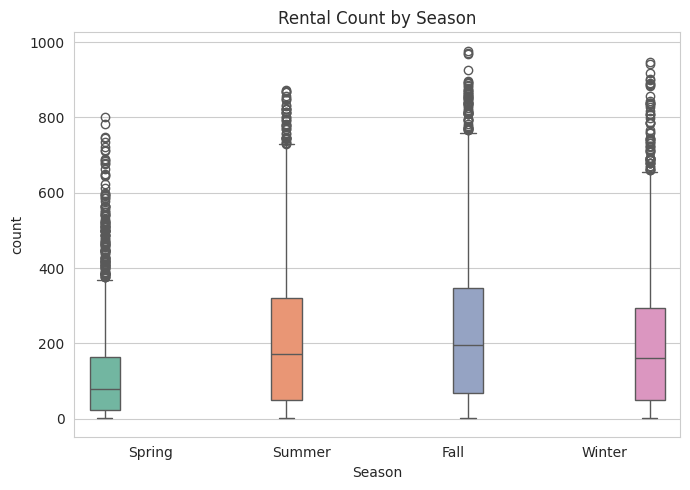

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_lab, x='season_lab', y='count', hue='season_lab', legend=False,
            order=order_map['season'], palette='Set2', ax=ax)
ax.set_title('Rental Count by Season')
ax.set_xlabel('Season')
plt.tight_layout()
plt.show()

**Observation:** Spring shows visibly lower rental counts than the other three seasons. Summer and Fall have the highest median demand, with Winter close behind — consistent with cycling being more attractive in warmer, non-monsoon months.

### 4.3 Weather vs. Count

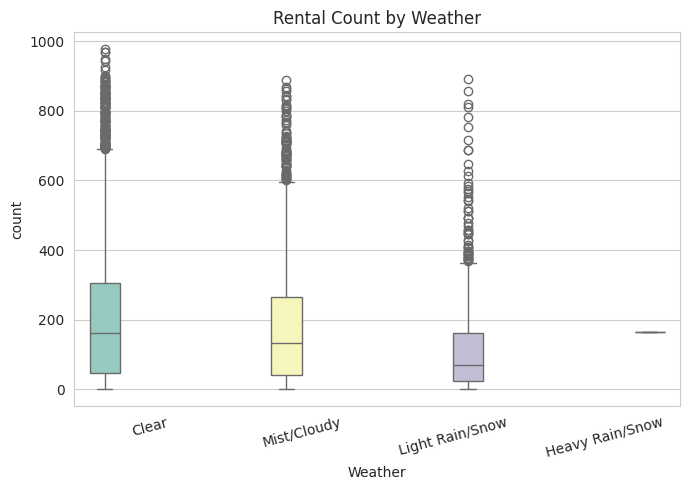

In [ ]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(data=df_lab, x='weather_lab', y='count', hue='weather_lab', legend=False,
            order=order_map['weather'], palette='Set3', ax=ax)
ax.set_title('Rental Count by Weather')
ax.set_xlabel('Weather')
ax.tick_params(axis='x', rotation=15)
plt.tight_layout()
plt.show()

**Observation:** Rentals fall as weather deteriorates — Clear weather has the highest counts, followed by Mist/Cloudy, then Light Rain/Snow, matching the intuition that adverse weather discourages cycling.

### 4.4 Average Demand by Season

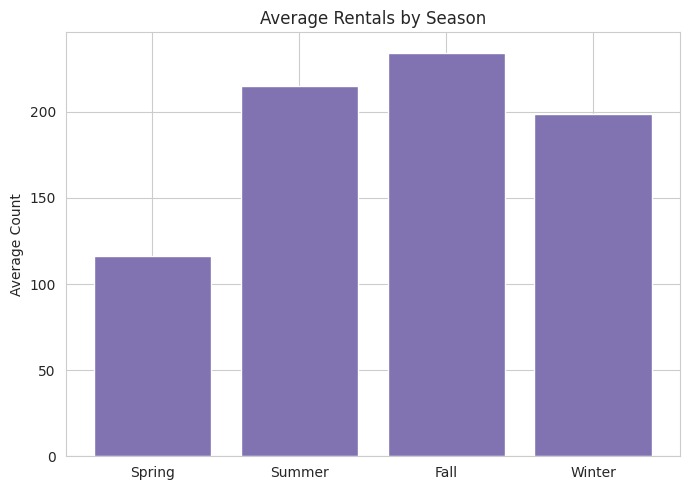

season_lab
Spring    116.343261
Summer    215.251372
Fall      234.417124
Winter    198.988296
Name: count, dtype: float64

In [ ]:
grp = df_lab.groupby('season_lab', observed=True)['count'].mean().reindex(order_map['season'])
fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(grp.index, grp.values, color='#8172B2')
ax.set_title('Average Rentals by Season')
ax.set_ylabel('Average Count')
plt.tight_layout()
plt.show()
grp

**Observation:** Average demand ranking by season is Fall > Summer > Winter > Spring, reinforcing the boxplot pattern above.

### 4.5 Correlation Between Continuous Variables

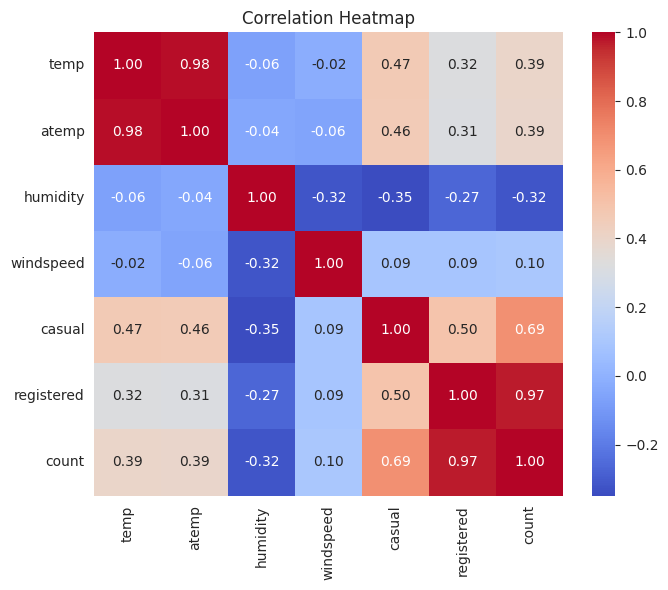

In [ ]:
fig, ax = plt.subplots(figsize=(7, 6))
corr = df[['temp', 'atemp', 'humidity', 'windspeed', 'casual', 'registered', 'count']].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap')
plt.tight_layout()
plt.show()

**Observations:**
- `temp` and `atemp` are almost perfectly correlated (~0.98) — only one is needed in a predictive model to avoid multicollinearity.
- `count` correlates positively with temp/atemp (~0.39) and negatively with humidity (~-0.32); windspeed shows a weak relationship — temperature and humidity look like the strongest continuous drivers of demand.
- `casual` and `registered` are both strongly correlated with `count` (by construction, since count is their sum), with `registered` contributing far more to total volume.

### 4.6 Season vs. Weather (Contingency Table)

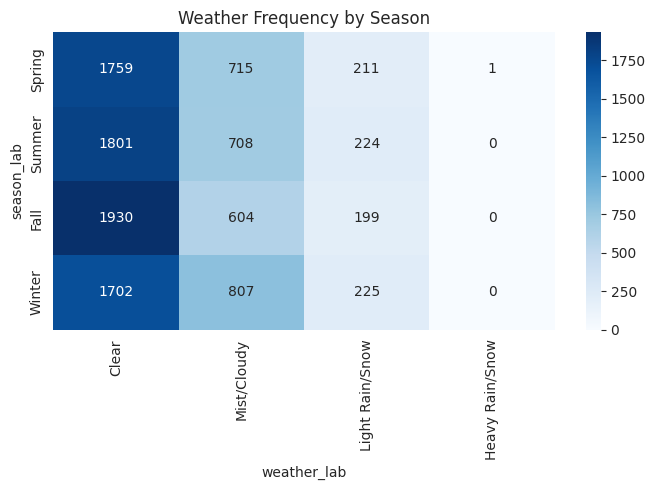

weather_lab,Clear,Mist/Cloudy,Light Rain/Snow,Heavy Rain/Snow
season_lab,,,,
Spring,1759,715,211,1
Summer,1801,708,224,0
Fall,1930,604,199,0
Winter,1702,807,225,0


In [ ]:
ct = pd.crosstab(df_lab['season_lab'], df_lab['weather_lab']).reindex(index=order_map['season'], columns=order_map['weather'])
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(ct, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_title('Weather Frequency by Season')
plt.tight_layout()
plt.show()
ct

**Observation:** Light Rain/Snow hours are noticeably more frequent in Spring (211) than Fall (199), and Mist/Cloudy hours are more common in Winter (807) than in Fall (604) — an early visual hint that weather type is not evenly distributed across seasons, tested formally in Section 5.3.

## 5. Hypothesis Testing

Significance level used throughout: **α = 0.05**

### 5.1 Two-Sample T-Test — Does Working Day affect rental count?

**H0:** The mean rental count is the same on working days and non-working days.
**H1:** The mean rental count differs between working days and non-working days.

In [ ]:
grp_work = df[df['workingday'] == 1]['count']
grp_nonwork = df[df['workingday'] == 0]['count']

print(f"Working day:     n={len(grp_work)}, mean={grp_work.mean():.2f}, std={grp_work.std():.2f}")
print(f"Non-working day: n={len(grp_nonwork)}, mean={grp_nonwork.mean():.2f}, std={grp_nonwork.std():.2f}")

Working day:     n=7412, mean=193.01, std=184.51
Non-working day: n=3474, mean=188.51, std=173.72


In [ ]:
# Assumption checks
lev_stat, lev_p = stats.levene(grp_work, grp_nonwork)
print(f"Levene's test (equal variance): stat={lev_stat:.3f}, p={lev_p:.4f}")

shap_w = stats.shapiro(grp_work.sample(min(len(grp_work), 5000), random_state=1))
shap_nw = stats.shapiro(grp_nonwork.sample(min(len(grp_nonwork), 5000), random_state=1))
print(f"Shapiro-Wilk (working day sample):     stat={shap_w.statistic:.4f}, p={shap_w.pvalue:.6f}")
print(f"Shapiro-Wilk (non-working day sample): stat={shap_nw.statistic:.4f}, p={shap_nw.pvalue:.6f}")

Levene's test (equal variance): stat=0.005, p=0.9438
Shapiro-Wilk (working day sample):     stat=0.8695, p=0.000000
Shapiro-Wilk (non-working day sample): stat=0.8852, p=0.000000


Levene's test shows equal variances hold (p = 0.944), so a standard Student's t-test is appropriate. Shapiro-Wilk rejects normality in both groups (p < 0.001), expected given the right-skew seen earlier — but by the Central Limit Theorem, the t-test remains valid for comparing means at this sample size (n > 3,000 per group), so we proceed while flagging the non-normality.

In [ ]:
t_stat, p_val = stats.ttest_ind(grp_work, grp_nonwork, equal_var=(lev_p > 0.05))
alpha = 0.05
print(f"t-statistic = {t_stat:.4f}, p-value = {p_val:.4f}")
print("Decision:", "Reject H0" if p_val < alpha else "Fail to reject H0")

t-statistic = 1.2096, p-value = 0.2264
Decision: Fail to reject H0


**Inference:** There is no statistically significant difference in average rental demand between working and non-working days (p = 0.226 > 0.05). Whether or not a day is a working day does not, by itself, meaningfully move total demand.

### 5.2a One-Way ANOVA — Does rental count differ across Seasons?

**H0:** Mean rental count is the same across all four seasons.
**H1:** At least one season's mean rental count differs from the others.

In [ ]:
season_groups = [df[df['season'] == s]['count'] for s in sorted(df['season'].unique())]
for s, g in zip(sorted(df['season'].unique()), season_groups):
    print(f"Season {s} ({season_labels[s]}): n={len(g)}, mean={g.mean():.2f}, std={g.std():.2f}")

Season 1 (Spring): n=2686, mean=116.34, std=125.27
Season 2 (Summer): n=2733, mean=215.25, std=192.01
Season 3 (Fall): n=2733, mean=234.42, std=197.15
Season 4 (Winter): n=2734, mean=198.99, std=177.62


In [ ]:
lev_stat_s, lev_p_s = stats.levene(*season_groups)
print(f"Levene's test: stat={lev_stat_s:.3f}, p={lev_p_s:.6f}")

f_stat_s, p_val_s = stats.f_oneway(*season_groups)
print(f"\nF-statistic = {f_stat_s:.4f}, p-value = {p_val_s:.6e}")
print("Decision:", "Reject H0" if p_val_s < alpha else "Fail to reject H0")

Levene's test: stat=187.771, p=0.000000

F-statistic = 236.9467, p-value = 6.164843e-149
Decision: Reject H0


Levene's test rejects equal variance (p < 0.001) and the underlying data is right-skewed rather than normal within groups. The classical one-way ANOVA is reported per the case instructions, with results treated as directional given these violations; group sizes are large and approximately equal (~2,700 each), which limits — but does not eliminate — the impact of unequal variances.

**Inference:** Season has a strong, statistically significant effect on rental demand (p ≈ 0). Fall and Summer generate the highest average demand, Spring the lowest — a difference far too large to be due to chance.

### 5.2b One-Way ANOVA — Does rental count differ across Weather?

**H0:** Mean rental count is the same across all weather categories.
**H1:** At least one weather category's mean rental count differs from the others.

In [ ]:
weather_groups = [df[df['weather'] == w]['count'] for w in sorted(df['weather'].unique())]
for w, g in zip(sorted(df['weather'].unique()), weather_groups):
    print(f"Weather {w} ({weather_labels[w]}): n={len(g)}, mean={g.mean():.2f}, std={g.std() if len(g) > 1 else float('nan'):.2f}")

Weather 1 (Clear): n=7192, mean=205.24, std=187.96
Weather 2 (Mist/Cloudy): n=2834, mean=178.96, std=168.37
Weather 3 (Light Rain/Snow): n=859, mean=118.85, std=138.58
Weather 4 (Heavy Rain/Snow): n=1, mean=164.00, std=nan


In [ ]:
lev_stat_w, lev_p_w = stats.levene(*weather_groups)
print(f"Levene's test: stat={lev_stat_w:.3f}, p={lev_p_w:.6f}")

f_stat_w, p_val_w = stats.f_oneway(*weather_groups)
print(f"\nF-statistic = {f_stat_w:.4f}, p-value = {p_val_w:.6e}")
print("Decision:", "Reject H0" if p_val_w < alpha else "Fail to reject H0")
print("\nNote: weather category 4 has only 1 observation — interpret with caution.")

Levene's test: stat=54.851, p=0.000000

F-statistic = 65.5302, p-value = 5.482069e-42
Decision: Reject H0

Note: weather category 4 has only 1 observation — interpret with caution.


Levene's test again rejects equal variance (p < 0.001), and group sizes are highly unbalanced (from n=7,192 down to n=1 for Heavy Rain/Snow), further weakening the reliability of the classical F-test for that category.

**Inference:** Weather condition significantly affects rental demand (p ≈ 0). Demand is highest in Clear weather and drops progressively as conditions worsen (Clear → Mist/Cloudy → Light Rain/Snow). The single Heavy Rain/Snow hour is not reliable evidence on its own and should be excluded from operational decisions.

### 5.3 Chi-Square Test — Is Weather dependent on Season?

**H0:** Weather condition is independent of season.
**H1:** Weather condition is dependent on season.

In [ ]:
ct_test = pd.crosstab(df['season'], df['weather'])
print(ct_test)

chi2, p_chi, dof, expected = stats.chi2_contingency(ct_test)
print(f"\nChi2 = {chi2:.4f}, dof = {dof}, p-value = {p_chi:.4f}")
print("Decision:", "Reject H0 (dependent)" if p_chi < alpha else "Fail to reject H0 (independent)")

weather     1    2    3  4
season                    
1        1759  715  211  1
2        1801  708  224  0
3        1930  604  199  0
4        1702  807  225  0

Chi2 = 49.1587, dof = 9, p-value = 0.0000
Decision: Reject H0 (dependent)


**Inference:** Weather and season are statistically dependent (p < 0.0001) — certain weather types are more likely in certain seasons (e.g., Mist/Cloudy conditions are relatively more common in Winter, and Fall sees the highest share of Clear weather). Season and weather are therefore not fully independent predictors: their combined effect should be considered in any demand model, and multicollinearity between the two should be checked before using both in a regression.

## 6. Key Insights

- **Working day is not a significant demand driver** (p = 0.226) — average hourly demand is statistically indistinguishable between working and non-working days.
- **Season is a highly significant demand driver** (p ≈ 0) — Fall and Summer see roughly 80–100% higher average demand than Spring.
- **Weather is a highly significant demand driver** (p ≈ 0) — demand drops as conditions worsen, from Clear (highest) to Light Rain/Snow (lowest reliable category).
- **Weather and season are statistically dependent** (p < 0.0001) — poor weather is not evenly spread across the year, so season's effect on demand is partly channeled through weather.
- `temp`/`atemp` and `humidity` show the strongest linear relationships with `count` among the continuous variables (r ≈ 0.39 and −0.32 respectively), while `windspeed` shows little linear association.
- Registered users contribute far more volume than casual users and likely represent steadier, more weather-tolerant commuter demand, while casual demand may be more discretionary and weather-sensitive.

## 7. Business Recommendations

- **Do not use weekday/weekend flags to plan fleet capacity** — since working day has no significant effect, resources should instead be allocated based on season and weather forecasts.
- **Build season- and weather-aware demand forecasts** — both are strong, statistically validated predictors and should anchor any pricing, rebalancing, or inventory model.
- **Target the Spring dip directly** — consider promotions, seasonal pricing, or maintenance scheduling concentrated in that period to smooth revenue across the year.
- **Plan weather-contingent operations** — proactively adjust fleet deployment ahead of forecast poor-weather hours, and increase availability on Clear-weather days, especially in Fall/Summer.
- **Investigate the registered-vs-casual split further** — loyalty/subscription-focused strategies may protect revenue more reliably than acquisition of casual riders.
- **Treat season and weather jointly, not independently**, in any predictive model given their statistically confirmed dependence — an interaction term or combined seasonal-weather index may outperform using either variable alone.